# Phase 1: load the libraries and data

In [54]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set a clean, professional aesthetic for our charts
sns.set_theme(style="whitegrid")
print("Libraries successfully loaded!")

# Load the data we saved at the end of the previous notebook
file_path = "../data/clean_cervical_cancer_data_ntb.csv"
df = pd.read_csv(file_path)

print(f"Data loaded! Shape: {df.shape[0]} patients and {df.shape[1]} features.")
df.head()

Libraries successfully loaded!
Data loaded! Shape: 856 patients and 34 features.


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18.0,4.0,15.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,15.0,1.0,14.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,34.0,1.0,20.795404,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,52.0,5.0,16.000000,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,46.0,3.0,21.000000,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Phase 2: Visual exploration

### Step 1: Plot the count of positive vs negative biopsies

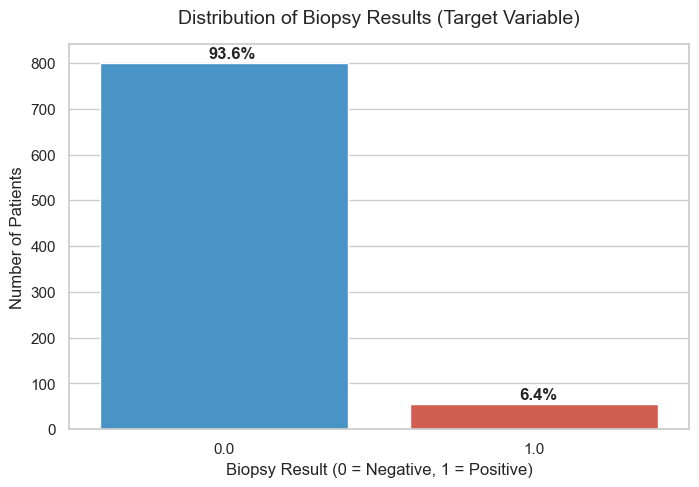

In [55]:
# Cell 2
plt.figure(figsize=(8, 5))

# Plot the count of positive vs negative biopsies
# FIX: Added hue='Biopsy' and legend=False to resolve the FutureWarning
ax = sns.countplot(
    data=df, 
    x='Biopsy', 
    hue='Biopsy', 
    palette=['#3498db', '#e74c3c'], 
    legend=False
)

plt.title("Distribution of Biopsy Results (Target Variable)", fontsize=14, pad=15)
plt.xlabel("Biopsy Result (0 = Negative, 1 = Positive)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Add percentage labels on top of the bars for clarity
total_patients = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total_patients:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 10
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')

plt.show()

### Step 2: Plot the correlation matrix

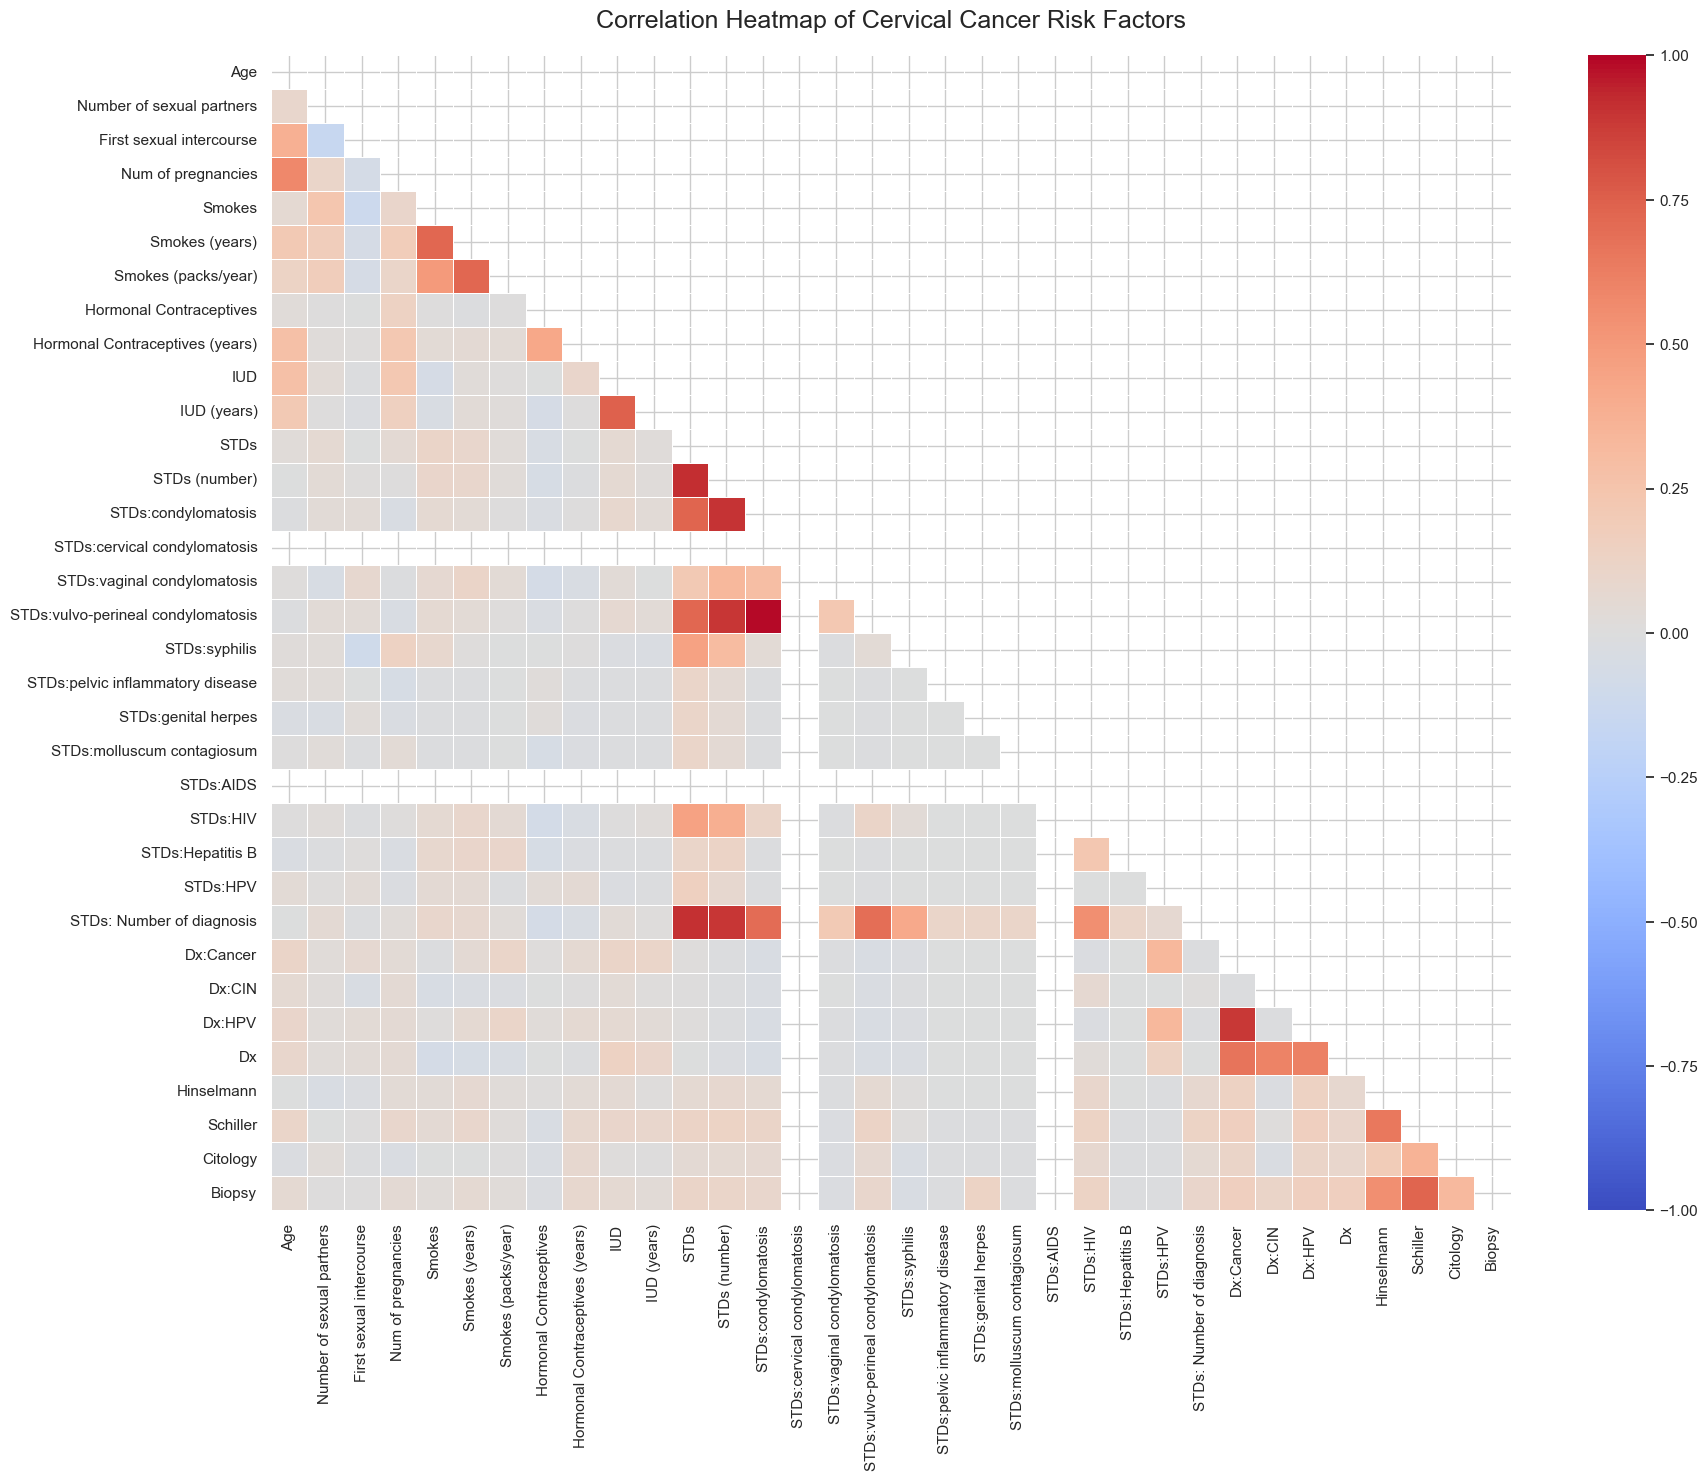

In [56]:
# Cell 3
plt.figure(figsize=(20, 15))

# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a mask to hide the upper triangle (prevents duplicate visual info)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=False, # Set to True if you want the exact numbers, but it gets crowded!
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            center=0, 
            linewidths=0.5)

plt.title("Correlation Heatmap of Cervical Cancer Risk Factors", fontsize=18, pad=20)
plt.show()

### Step 3: Investigating zero-variance and collinearity

In [57]:
# Cell 4
print("==========================================")
print("PHASE 2, STEP 3: FEATURE INVESTIGATION")
print("==========================================")

# ---------------------------------------------------------
# Part A: Prove Zero-Variance
# ---------------------------------------------------------
print("--- Part A: Zero-Variance Check ---")
suspect_cols = ['STDs:cervical condylomatosis', 'STDs:AIDS']

for col in suspect_cols:
    unique_vals = df[col].unique()
    print(f"Unique values in '{col}': {unique_vals}")

# ---------------------------------------------------------
# Part B: Identify Highly Correlated Pairs
# ---------------------------------------------------------
print("\n--- Part B: High Correlation Pairs (> 0.80) ---")

# Calculate absolute correlation (so we catch strong negative correlations too)
corr_matrix_abs = df.corr().abs()

# Keep only the upper triangle to avoid duplicating A vs B and B vs A
upper_mask = np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool)
upper = corr_matrix_abs.where(upper_mask)

# Set our threshold
threshold = 0.80

# Stack the matrix and filter by the threshold
stacked = upper.stack()
high_corr_pairs = stacked[stacked > threshold]

if len(high_corr_pairs) > 0:
    print(f"Found {len(high_corr_pairs)} highly correlated pairs:\n")
    for index, value in high_corr_pairs.items():
        feature_A, feature_B = index
        print(f"- {feature_A}  <--->  {feature_B}  (Correlation: {value:.2f})")
else:
    print("No highly correlated pairs found above the threshold.")

PHASE 2, STEP 3: FEATURE INVESTIGATION
--- Part A: Zero-Variance Check ---
Unique values in 'STDs:cervical condylomatosis': [0.]
Unique values in 'STDs:AIDS': [0.]

--- Part B: High Correlation Pairs (> 0.80) ---
Found 7 highly correlated pairs:

- STDs  <--->  STDs (number)  (Correlation: 0.92)
- STDs  <--->  STDs: Number of diagnosis  (Correlation: 0.91)
- STDs (number)  <--->  STDs:condylomatosis  (Correlation: 0.90)
- STDs (number)  <--->  STDs:vulvo-perineal condylomatosis  (Correlation: 0.89)
- STDs (number)  <--->  STDs: Number of diagnosis  (Correlation: 0.90)
- STDs:condylomatosis  <--->  STDs:vulvo-perineal condylomatosis  (Correlation: 0.99)
- Dx:Cancer  <--->  Dx:HPV  (Correlation: 0.89)


### Step 4: Condylomatosis Verification and final drops

In [58]:
# Cell 5
print("==========================================")
print("PHASE 2, STEP 4: VERIFICATION & DROPPING")
print("==========================================")

# ---------------------------------------------------------
# Part A: Verify the Condylomatosis Hypothesis
# ---------------------------------------------------------
print("--- Part A: Condylomatosis Logic Check ---")

# Gather the specific condylomatosis columns (ignoring the master and the zero-variance one)
specific_condy_cols = ['STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis']

# Create a flag: 1 if they have ANY specific condylomatosis, 0 if not
has_specific_condy = (df[specific_condy_cols].sum(axis=1) > 0).astype(int)

# Check if this flag perfectly matches the master 'STDs:condylomatosis' column
mismatches = df[df['STDs:condylomatosis'] != has_specific_condy]

print(f"Number of patients where master 'condylomatosis' contradicts the specific columns: {len(mismatches)}")

# ---------------------------------------------------------
# Part B: Execute the Drops
# ---------------------------------------------------------
print("\n--- Part B: Dropping Redundant & Empty Features ---")

# We start with the ones we know for sure
columns_to_drop = [
    'STDs:cervical condylomatosis', # Zero variance
    'STDs:AIDS',                    # Zero variance
    # 'STDs'                          # Redundant to STDs (number) #TODO::::::::::::::::::
]

# If the logic check passed, we safely add the master condylomatosis column to the chopping block #TODO
# if len(mismatches) == 0:
#     print("Hypothesis confirmed! 'STDs:condylomatosis' is a redundant master column. Adding to drop list.")
#     columns_to_drop.append('STDs:condylomatosis')
# else:
#     print("Warning: Mismatches found. Keeping 'STDs:condylomatosis' just in case.")

# Execute the drop
df_final = df.drop(columns=columns_to_drop)

print(f"\nSuccessfully dropped {len(columns_to_drop)} columns.")
print(f"Original Shape: {df.shape}")
print(f"Final Cleaned Shape: {df_final.shape}")

# Overwrite our working dataframe with the final version
df = df_final

PHASE 2, STEP 4: VERIFICATION & DROPPING
--- Part A: Condylomatosis Logic Check ---
Number of patients where master 'condylomatosis' contradicts the specific columns: 0

--- Part B: Dropping Redundant & Empty Features ---

Successfully dropped 2 columns.
Original Shape: (856, 34)
Final Cleaned Shape: (856, 32)


In [59]:
# Cell 6 #TODO
# print("--- Fixing Data Leakage ---")

# # Drop the concurrent medical tests
# leakage_cols = ['Schiller', 'Hinselmann', 'Citology']
# df = df.drop(columns=leakage_cols, errors='ignore')

# print(f"Dropped {len(leakage_cols)} data-leaking test columns.")
# print(f"New dataset shape: {df.shape[0]} patients and {df.shape[1]} features.")

# Phase 3: Clean data visual exploration

### Step 1: Cleaned correlation matrix

PHASE 3: CLEAN DATA VISUAL EXPLORATION
--- Step 1: Cleaned Correlation Matrix ---


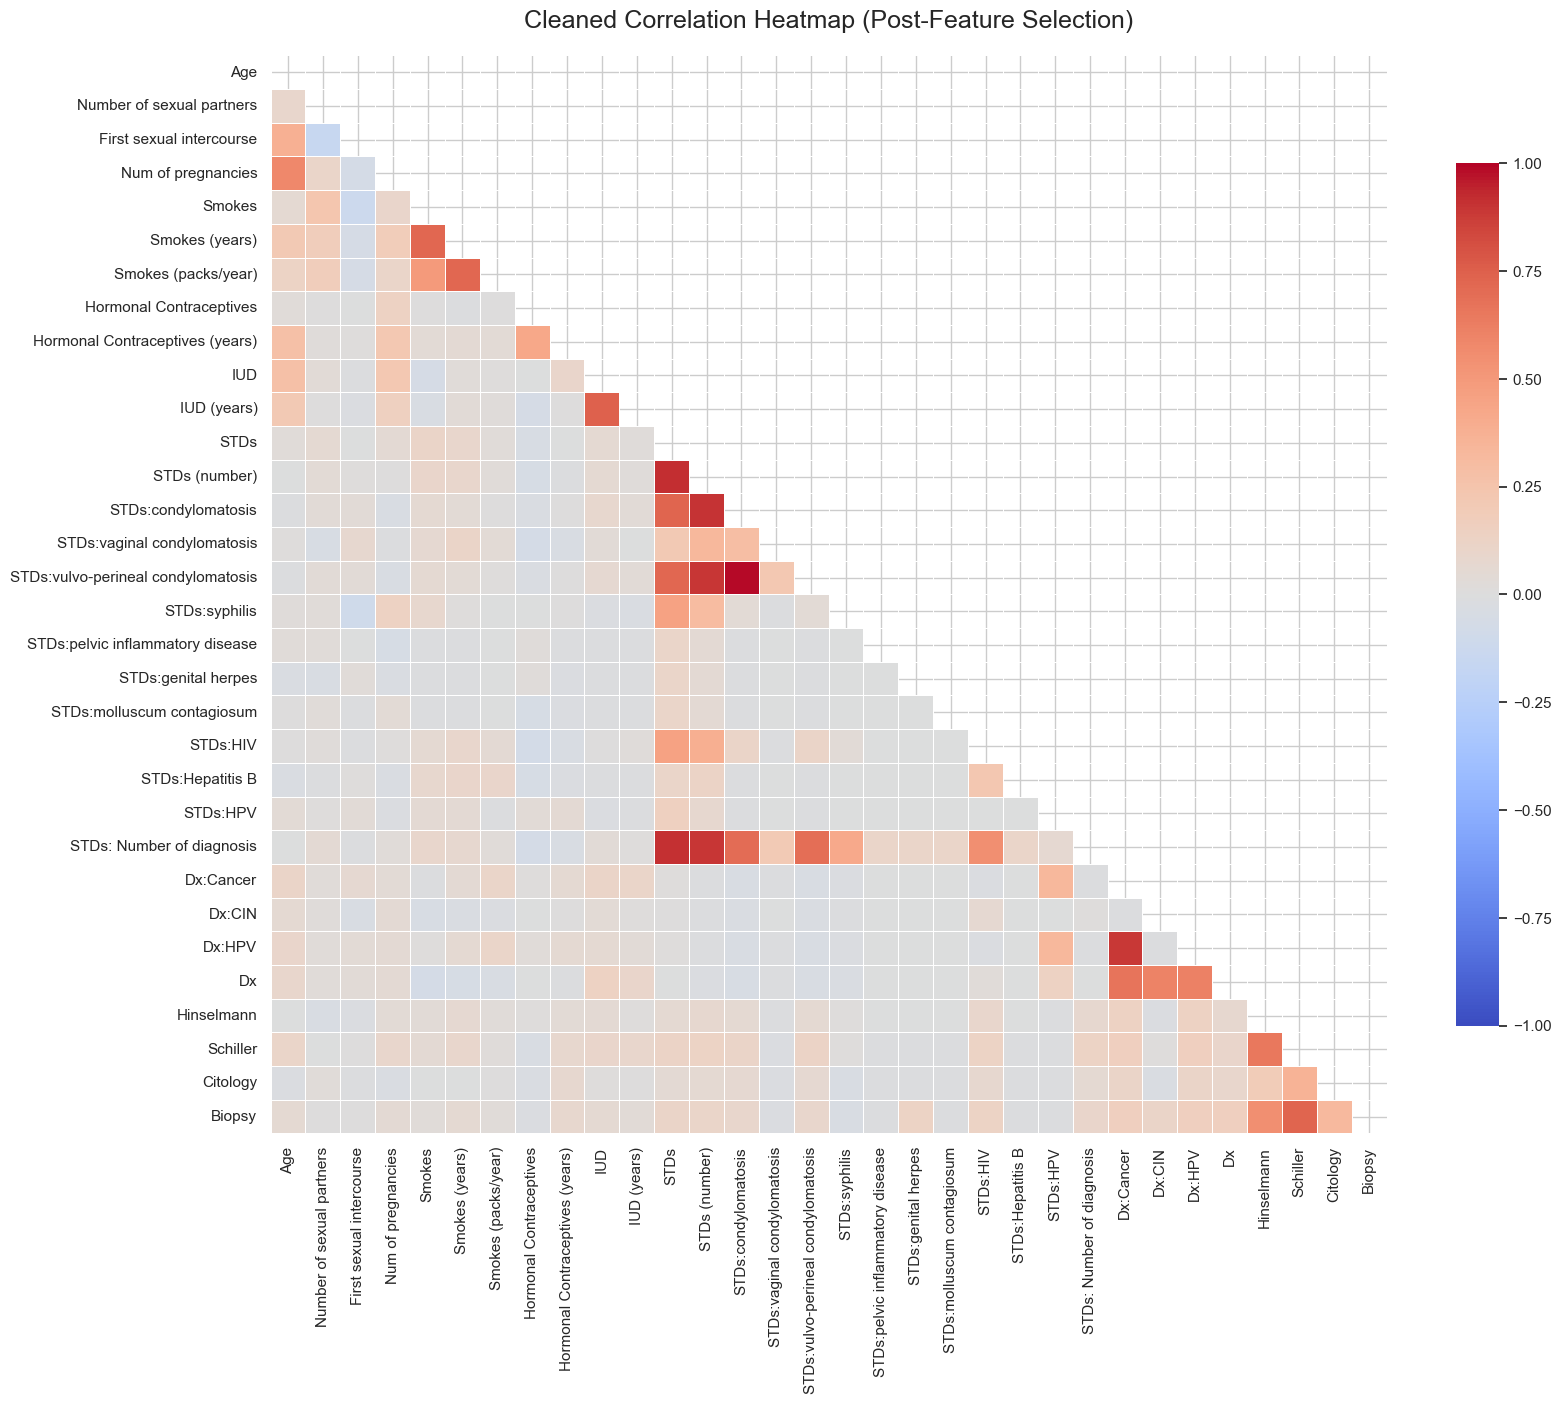


--- Top Features Correlated with Positive Biopsy ---
Schiller      0.733
Hinselmann    0.547
Citology      0.327
Dx:Cancer     0.161
Dx:HPV        0.161
Name: Biopsy, dtype: float64


In [60]:
# Cell 7
print("==========================================")
print("PHASE 3: CLEAN DATA VISUAL EXPLORATION")
print("==========================================")
print("--- Step 1: Cleaned Correlation Matrix ---")

# Set up the canvas
plt.figure(figsize=(18, 14))

# Calculate the new correlation matrix on the cleaned dataframe
clean_corr = df.corr()

# Create the mask to hide the upper triangle
mask = np.triu(np.ones_like(clean_corr, dtype=bool))

# Plot the heatmap
sns.heatmap(clean_corr, 
            mask=mask, 
            annot=False, # Keeping this False so it remains readable
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            center=0, 
            linewidths=0.5,
            cbar_kws={"shrink": .8}) # Shrinks the colorbar slightly for aesthetics

plt.title("Cleaned Correlation Heatmap (Post-Feature Selection)", fontsize=18, pad=20)
plt.show()

# Let's also print the top correlations strictly with our Target Variable (Biopsy)
print("\n--- Top Features Correlated with Positive Biopsy ---")
target_corr = clean_corr['Biopsy'].drop('Biopsy').sort_values(ascending=False)
print(target_corr.head(5).round(3))

### Step 2: Continuous feature investigation

PHASE 3, STEP 2: CONTINUOUS FEATURE INVESTIGATION


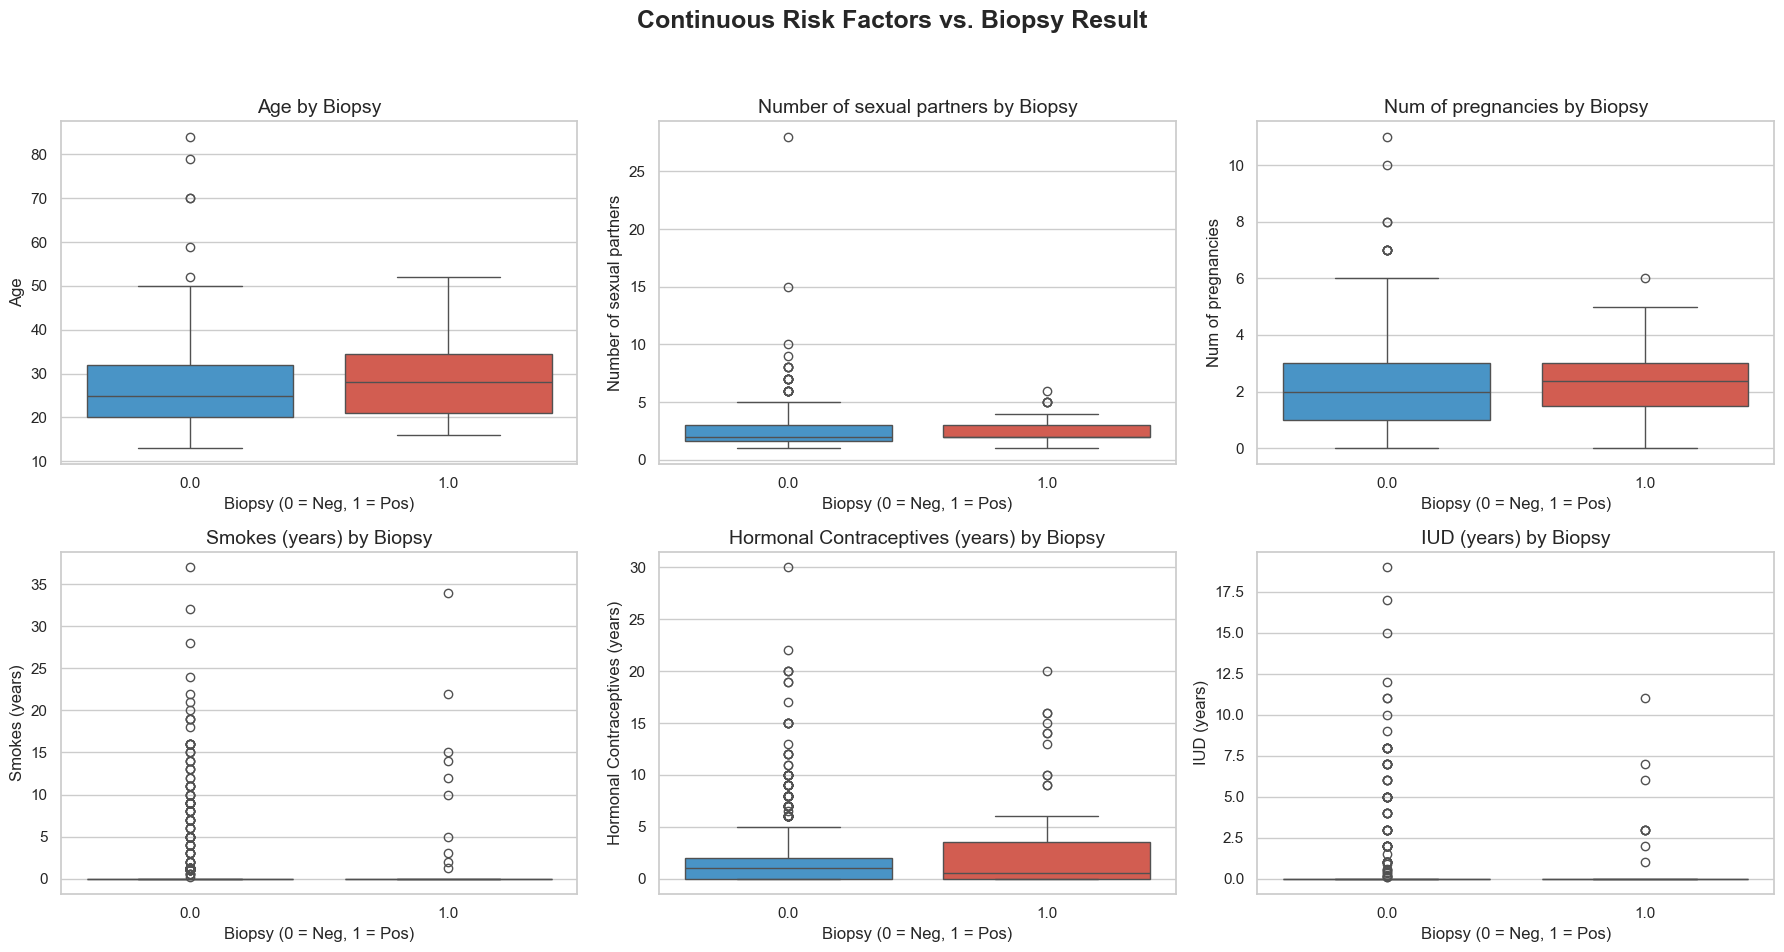

In [61]:
# Cell 8
print("==========================================")
print("PHASE 3, STEP 2: CONTINUOUS FEATURE INVESTIGATION")
print("==========================================")

# List of the main continuous features we want to investigate
continuous_features = [
    'Age', 
    'Number of sexual partners', 
    'Num of pregnancies', 
    'Smokes (years)', 
    'Hormonal Contraceptives (years)', 
    'IUD (years)'
]

# Set up a grid for our plots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Continuous Risk Factors vs. Biopsy Result', fontsize=18, fontweight='bold')

# Flatten the axes array so we can easily loop through it
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    # Create a boxplot for each feature, split by Biopsy result
    sns.boxplot(
        x='Biopsy', 
        y=feature, 
        data=df, 
        ax=axes[i], 
        palette=['#3498db', '#e74c3c'],
        hue='Biopsy',
        legend=False
    )
    axes[i].set_title(f'{feature} by Biopsy', fontsize=14)
    axes[i].set_xlabel('Biopsy (0 = Neg, 1 = Pos)')
    axes[i].set_ylabel(feature)

# Adjust spacing so the labels don't overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Step 3: Categorical feature investigation

PHASE 3, STEP 3: CATEGORICAL FEATURE INVESTIGATION


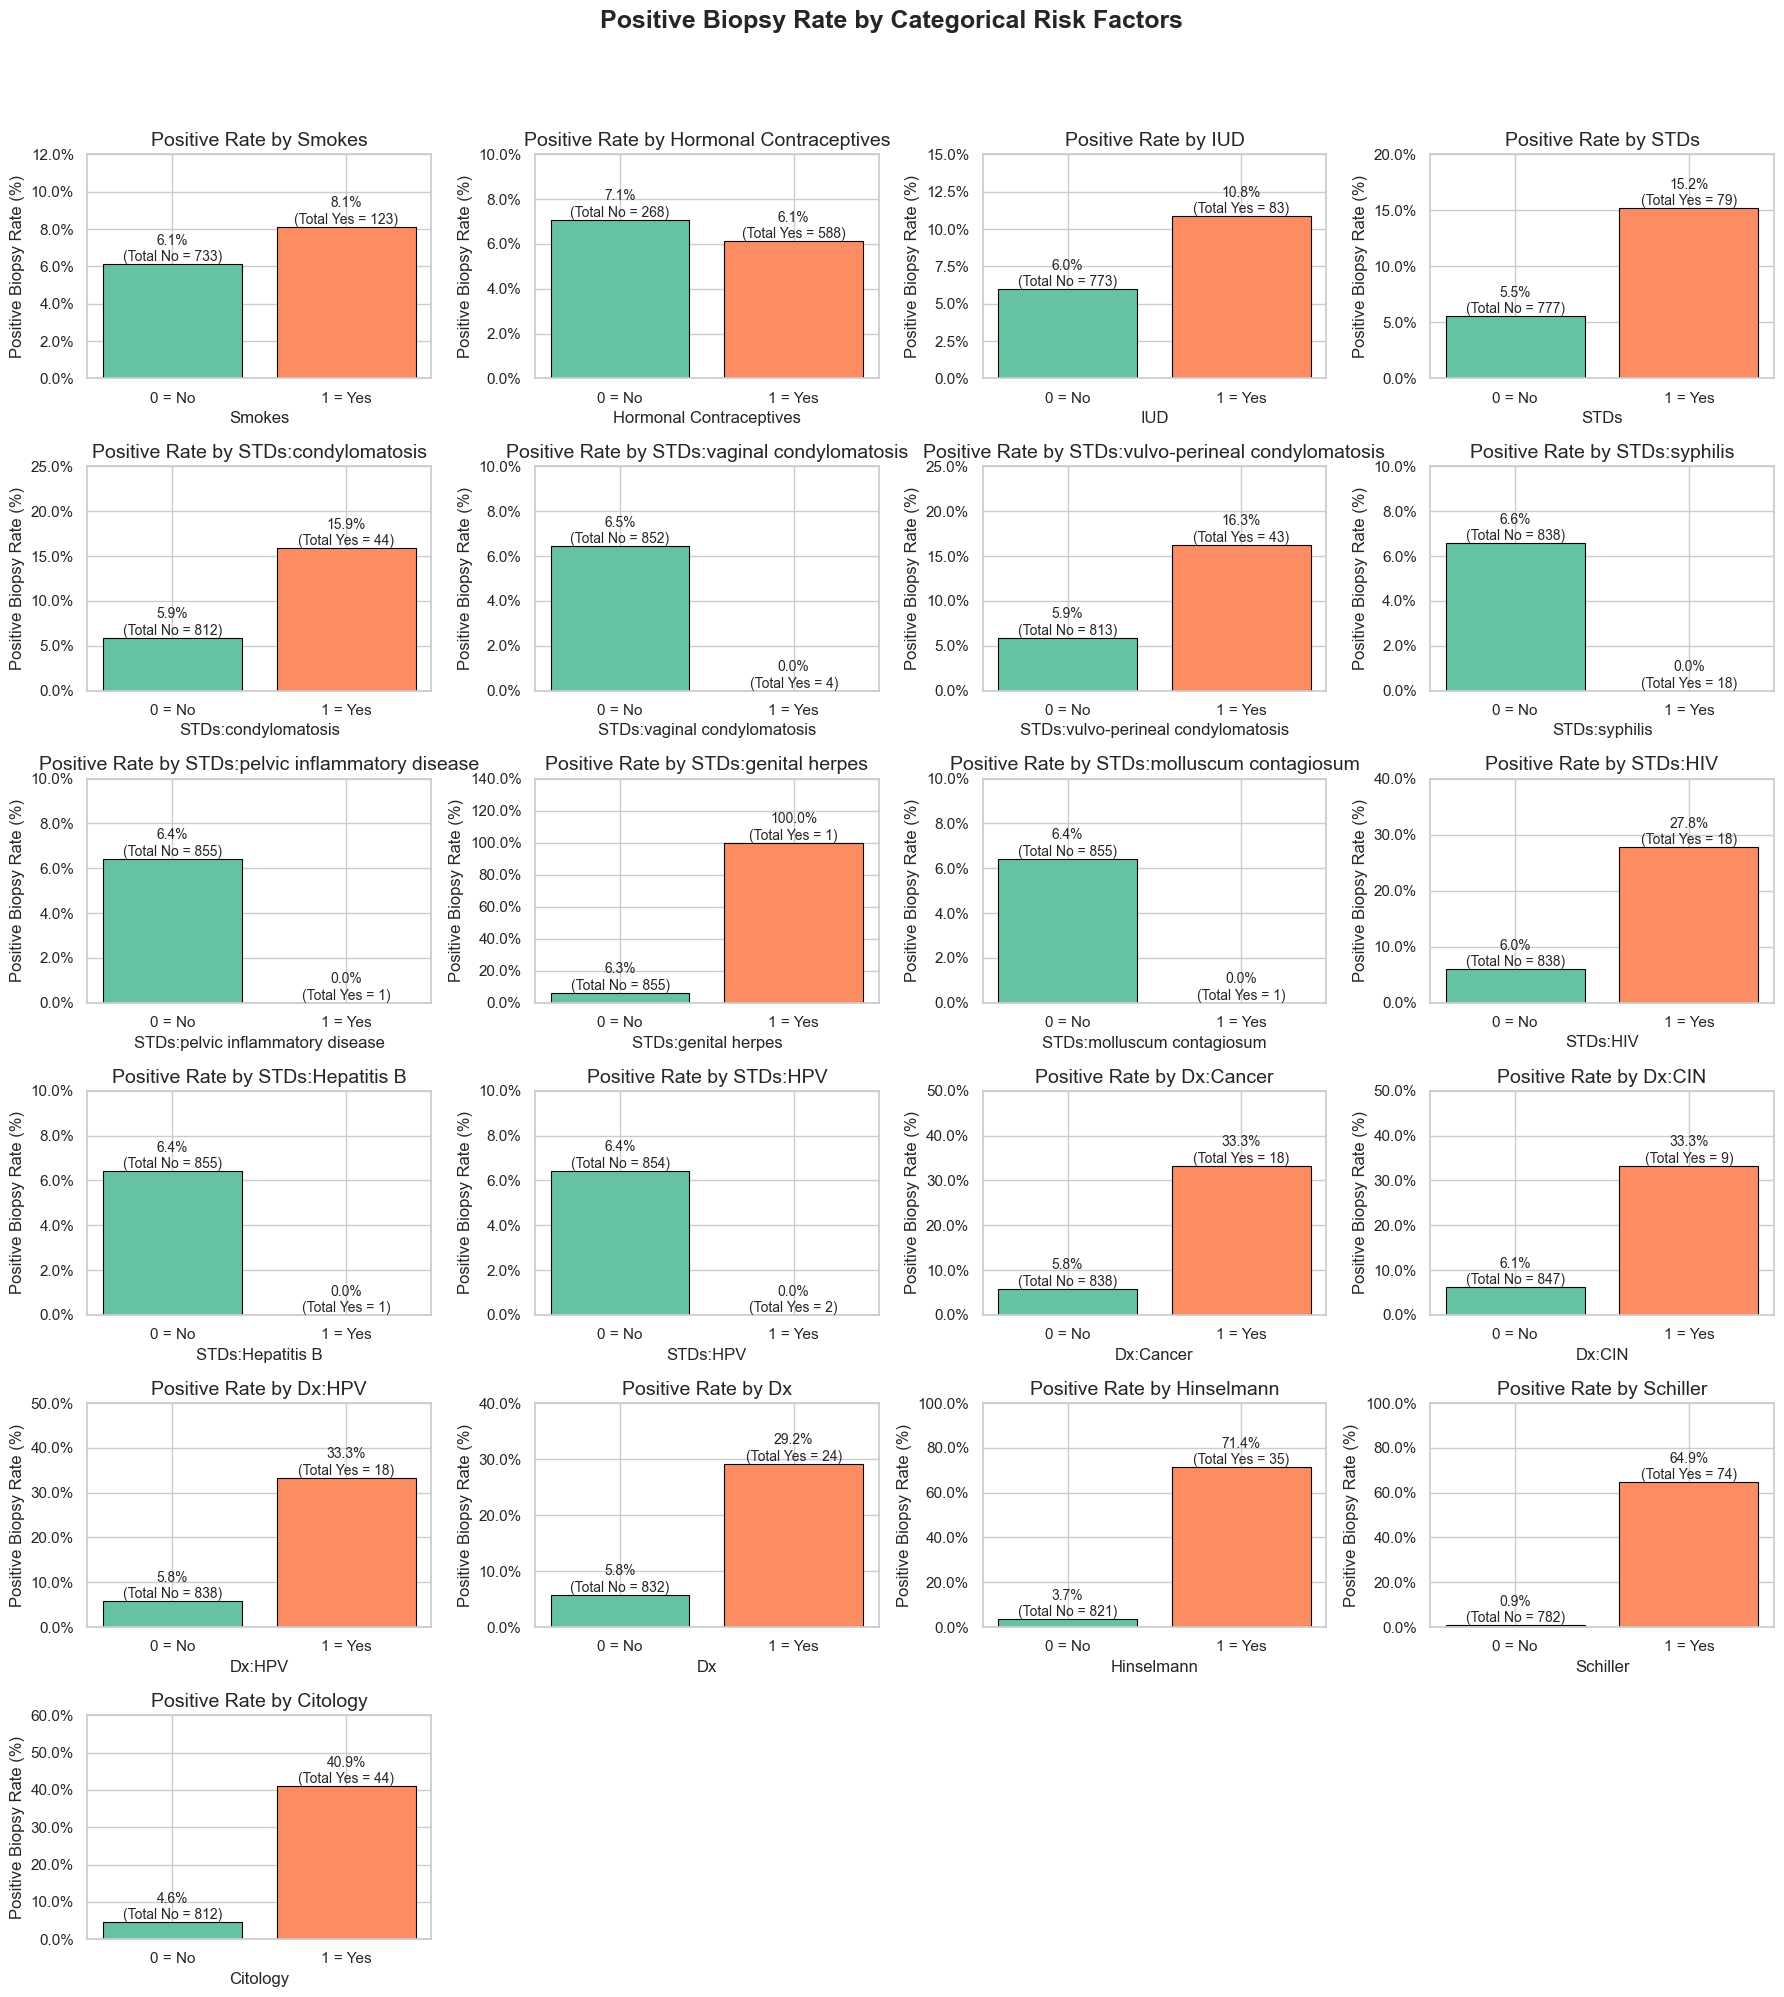

In [62]:
# Cell 9
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("==========================================")
print("PHASE 3, STEP 3: CATEGORICAL FEATURE INVESTIGATION")
print("==========================================")

# Dynamically select binary categorical features
categorical_features = [col for col in df.columns if set(df[col].dropna().unique()).issubset({0.0, 1.0}) and col != 'Biopsy']

# Determine dynamic grid dimensions
n_features = len(categorical_features)
n_cols = 4  
n_rows = (n_features - 1) // n_cols + 1  

# Set up the dynamic grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
fig.suptitle('Positive Biopsy Rate by Categorical Risk Factors', fontsize=18, fontweight='bold')

axes = axes.flatten()

# Extract 'Set2' hex codes to maintain your exact color scheme
color_no = '#66c2a5'  # Set2 Green
color_yes = '#fc8d62' # Set2 Orange

for i, feature in enumerate(categorical_features):
    ax = axes[i]
    
    # Rigorously calculate the exact rates and counts from the dataframe
    rates = []
    counts = []
    
    for cat in [0.0, 1.0]:
        subset = df[df[feature] == cat]
        count = len(subset)
        counts.append(count)
        
        if count > 0:
            # Calculate the mathematical mean (Positive Rate)
            rate = subset['Biopsy'].mean()
            # Handle edge cases where Biopsy data might be entirely NaN for this subset
            rate = 0.0 if pd.isna(rate) else rate
        else:
            # If the category doesn't exist in the data, the rate is strictly 0
            rate = 0.0
            
        rates.append(rate)
        
    # Draw bars using absolute Matplotlib geometry to prevent Seaborn artifacts
    bars = ax.bar(
        x=[0, 1], 
        height=rates, 
        color=[color_no, color_yes],
        edgecolor='black', # Forces a visible line even if height is exactly 0
        linewidth=0.8
    )
    
    ax.set_title(f'Positive Rate by {feature}', fontsize=14)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0 = No', '1 = Yes'])
    ax.set_xlabel(f'{feature}')
    ax.set_ylabel('Positive Biopsy Rate (%)')
    
    # Map the text perfectly to the static coordinates
    max_rate = max(rates)
    
    for j, bar in enumerate(bars):
        # Only annotate the bar if the data actually exists in the dataset
        if counts[j] > 0:
            label = f'{rates[j]:.1%}\n(Total {"No" if j == 0 else "Yes"} = {counts[j]})'
            ax.text(
                x=bar.get_x() + bar.get_width() / 2, 
                y=rates[j], 
                s=label, 
                ha='center', 
                va='bottom', 
                fontsize=10
            )
            
    # Dynamically scale the y-axis, ensuring a minimum bound so 0% plots do not squash
    ymax = max_rate * 1.3 if max_rate > 0 else 0.1
    ax.set_ylim(0, ymax) 
    
    # Format the y-axis as percentages
    vals = ax.get_yticks()
    ax.set_yticks(vals) 
    ax.set_yticklabels(['{:,.1%}'.format(x) for x in vals])
    
# Cleanly hide any remaining unused subplots 
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust global spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Step 4: Statistical significance testing

In [63]:
# Cell 10
import scipy.stats as stats

print("==========================================")
print("PHASE 3, STEP 4: STATISTICAL SIGNIFICANCE TESTING")
print("==========================================")

# ---------------------------------------------------------
# 1. Continuous Features (Mann-Whitney U Test)
# ---------------------------------------------------------
print("--- Continuous Features (Target: Biopsy) ---")
print("Null Hypothesis: The feature distribution is the same for Negative and Positive biopsies.\n")

continuous_features = [
    'Age', 'Number of sexual partners', 'Num of pregnancies', 
    'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 
    'IUD (years)', 'STDs (number)', 'STDs: Number of diagnosis'
]

# Only test columns that still exist in our dataframe
for feature in continuous_features:
    if feature in df.columns:
        group_neg = df[df['Biopsy'] == 0][feature].dropna()
        group_pos = df[df['Biopsy'] == 1][feature].dropna()
        
        stat, p_value = stats.mannwhitneyu(group_neg, group_pos, alternative='two-sided')
        significance = "SIGNIFICANT" if p_value < 0.05 else "Not Significant"
        print(f"- {feature:32} | p-value: {p_value:.4f} ({significance})")

# ---------------------------------------------------------
# 2. Categorical Features (Chi-Square Test)
# ---------------------------------------------------------
print("\n--- Categorical Features (Target: Biopsy) ---")
print("Null Hypothesis: The feature and Biopsy result are independent.\n")

# Dynamically find all binary categorical columns (excluding our target 'Biopsy')
categorical_features = [col for col in df.columns if set(df[col].dropna().unique()).issubset({0.0, 1.0}) and col != 'Biopsy']

for feature in categorical_features:
    # Ensure the column actually has variance (has both 0s and 1s) to avoid math errors
    if df[feature].nunique() > 1:
        contingency_table = pd.crosstab(df[feature], df['Biopsy'])
        chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
        
        significance = "SIGNIFICANT" if p_value < 0.05 else "Not Significant"
        print(f"- {feature:32} | p-value: {p_value:.4f} ({significance})")

PHASE 3, STEP 4: STATISTICAL SIGNIFICANCE TESTING
--- Continuous Features (Target: Biopsy) ---
Null Hypothesis: The feature distribution is the same for Negative and Positive biopsies.

- Age                              | p-value: 0.1205 (Not Significant)
- Number of sexual partners        | p-value: 0.6445 (Not Significant)
- Num of pregnancies               | p-value: 0.0183 (SIGNIFICANT)
- Smokes (years)                   | p-value: 0.3399 (Not Significant)
- Smokes (packs/year)              | p-value: 0.3444 (Not Significant)
- Hormonal Contraceptives (years)  | p-value: 0.8770 (Not Significant)
- IUD (years)                      | p-value: 0.0835 (Not Significant)
- STDs (number)                    | p-value: 0.0002 (SIGNIFICANT)
- STDs: Number of diagnosis        | p-value: 0.0012 (SIGNIFICANT)

--- Categorical Features (Target: Biopsy) ---
Null Hypothesis: The feature and Biopsy result are independent.

- Smokes                           | p-value: 0.5257 (Not Significant)
- Ho

In [64]:
print("STDs:HPV counts:\n", df['STDs:HPV'].value_counts())
print("\nDx:HPV counts:\n", df['Dx:HPV'].value_counts())

STDs:HPV counts:
 STDs:HPV
0.0    854
1.0      2
Name: count, dtype: int64

Dx:HPV counts:
 Dx:HPV
0.0    838
1.0     18
Name: count, dtype: int64
